# EDA and Feature Engineering for Fraud Detection
This notebook covers the Exploratory Data Analysis and data preparation steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import os

import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [2]:
data_path = '../data/creditcard.csv'
print(f"Loading data from {data_path}...")
df = pd.read_csv(data_path)
print("Data loaded successfully.")
print(df.isnull().sum()) # Affiche le nombre de valeurs manquantes par colonne
# Vérifier le nombre de doublons
print(f"Nombre de doublons : {df.duplicated().sum()}") 

# Supprimer les doublons (pour nettoyer le dataset)
df = df.drop_duplicates()



Loading data from ../data/creditcard.csv...


Data loaded successfully.
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Nombre de doublons : 1081


### 1. Target Variable Analysis (Class Imbalance)

Class
0    283253
1       473
Name: count, dtype: int64
Fraud Percentage: 0.167%


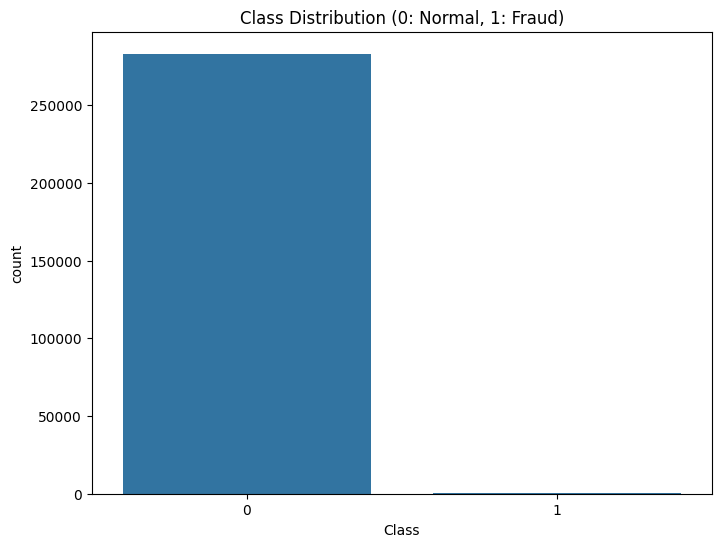

In [3]:
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"Fraud Percentage: {class_counts[1] / len(df) * 100:.3f}%")

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.show()

### 2. Univariate Analysis (Distribution)

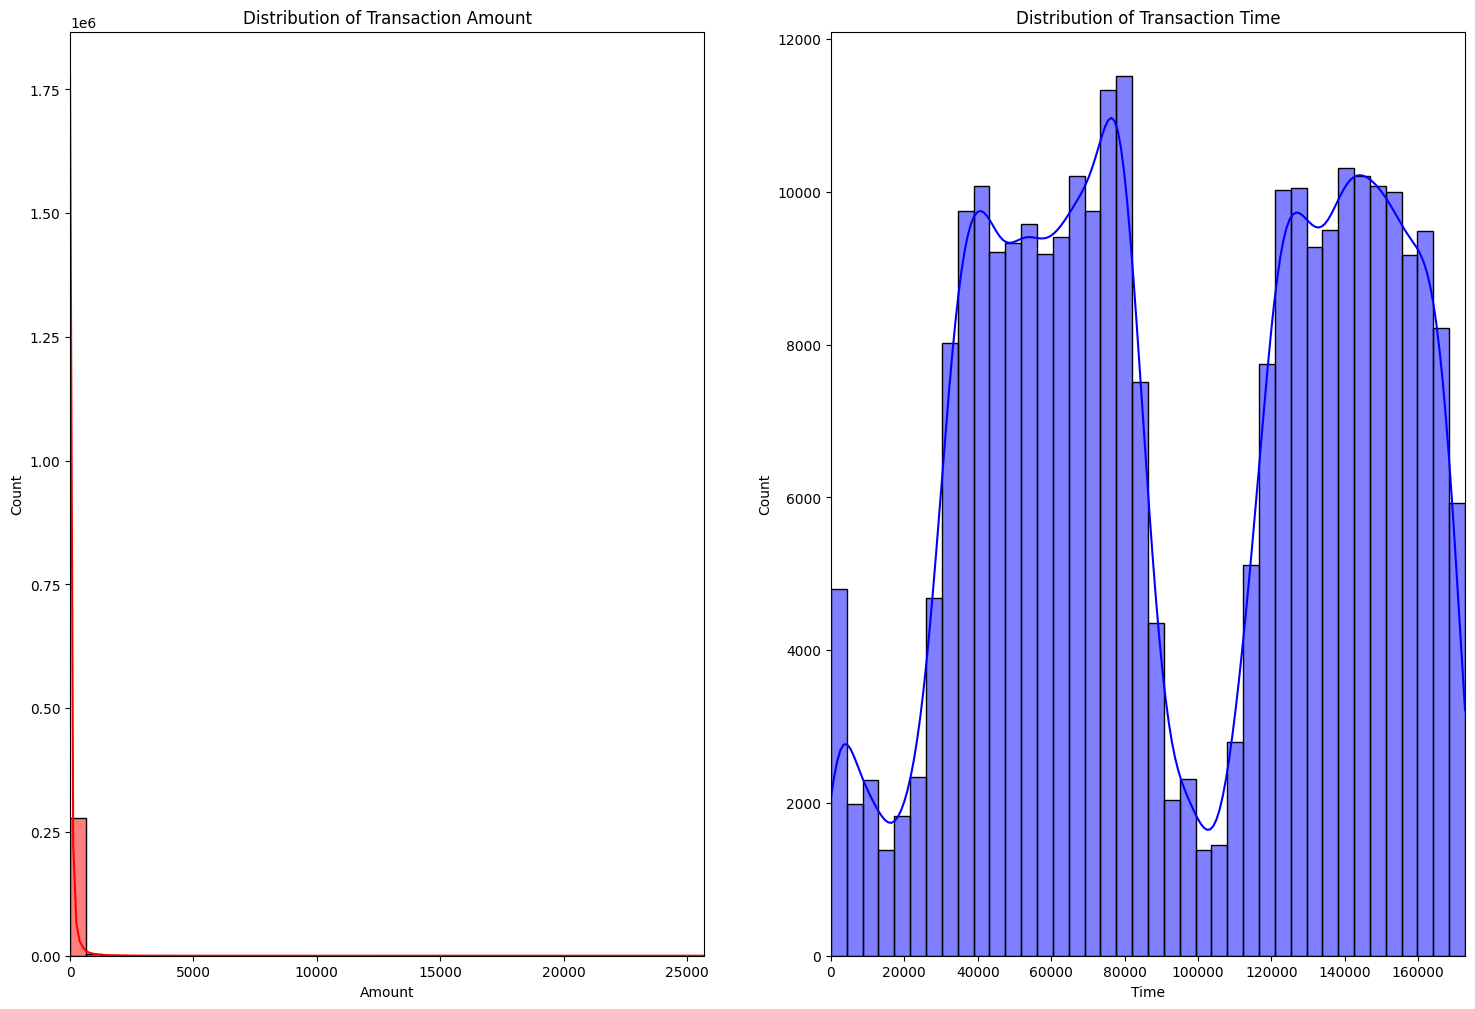

In [4]:
# Analyzing 'Amount' and 'Time'
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
sns.histplot(df['Amount'], bins=40, ax=axes[0], color='r', kde=True)
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlim([min(df['Amount']), max(df['Amount'])])

sns.histplot(df['Time'], bins=40, ax=axes[1], color='b', kde=True)
axes[1].set_title('Distribution of Transaction Time')
axes[1].set_xlim([min(df['Time']), max(df['Time'])])
plt.show()

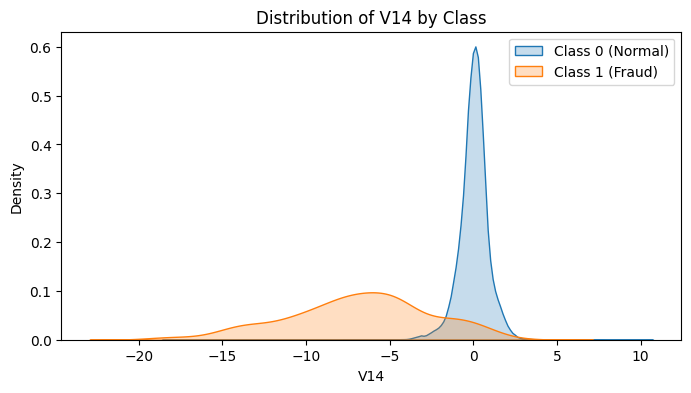

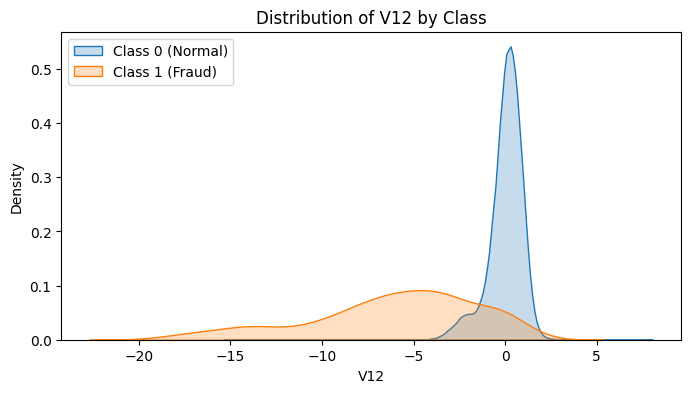

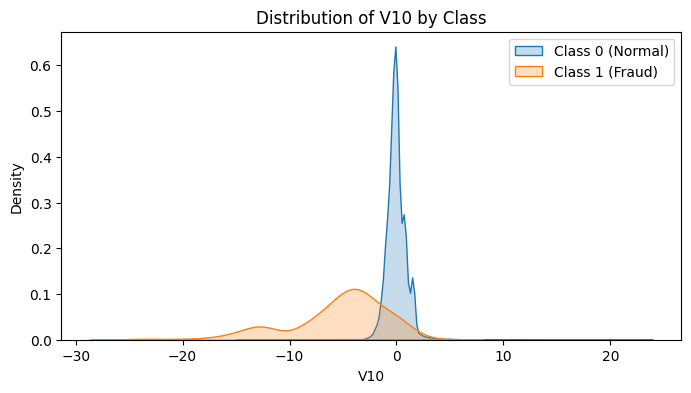

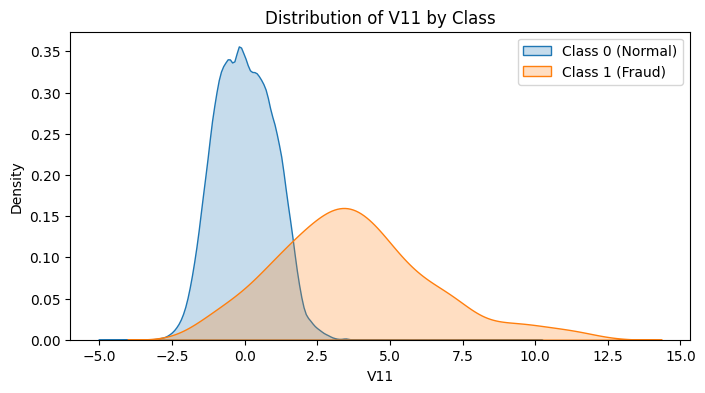

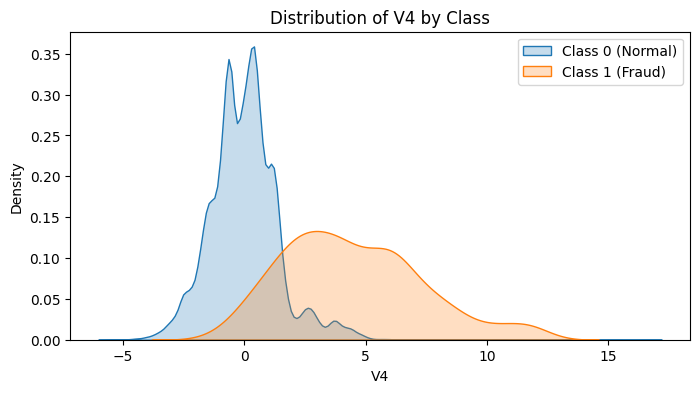

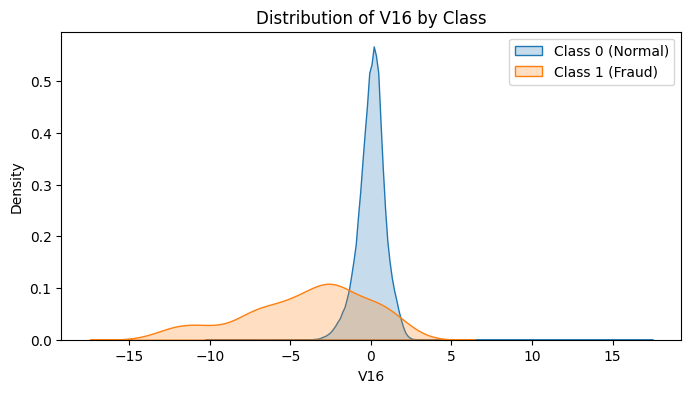

In [5]:
# Example of comparing a V feature distribution between Fraud and Normal
features_to_plot = ['V14', 'V12', 'V10', 'V11', 'V4', 'V16']

for feature in features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df[df['Class'] == 0], x=feature, label="Class 0 (Normal)", fill=True)
    sns.kdeplot(data=df[df['Class'] == 1], x=feature, label="Class 1 (Fraud)", fill=True)
    plt.title(f'Distribution of {feature} by Class')
    plt.legend()
    plt.show()

### 3. Correlation Analysis (Pearson & Sub-sampling)

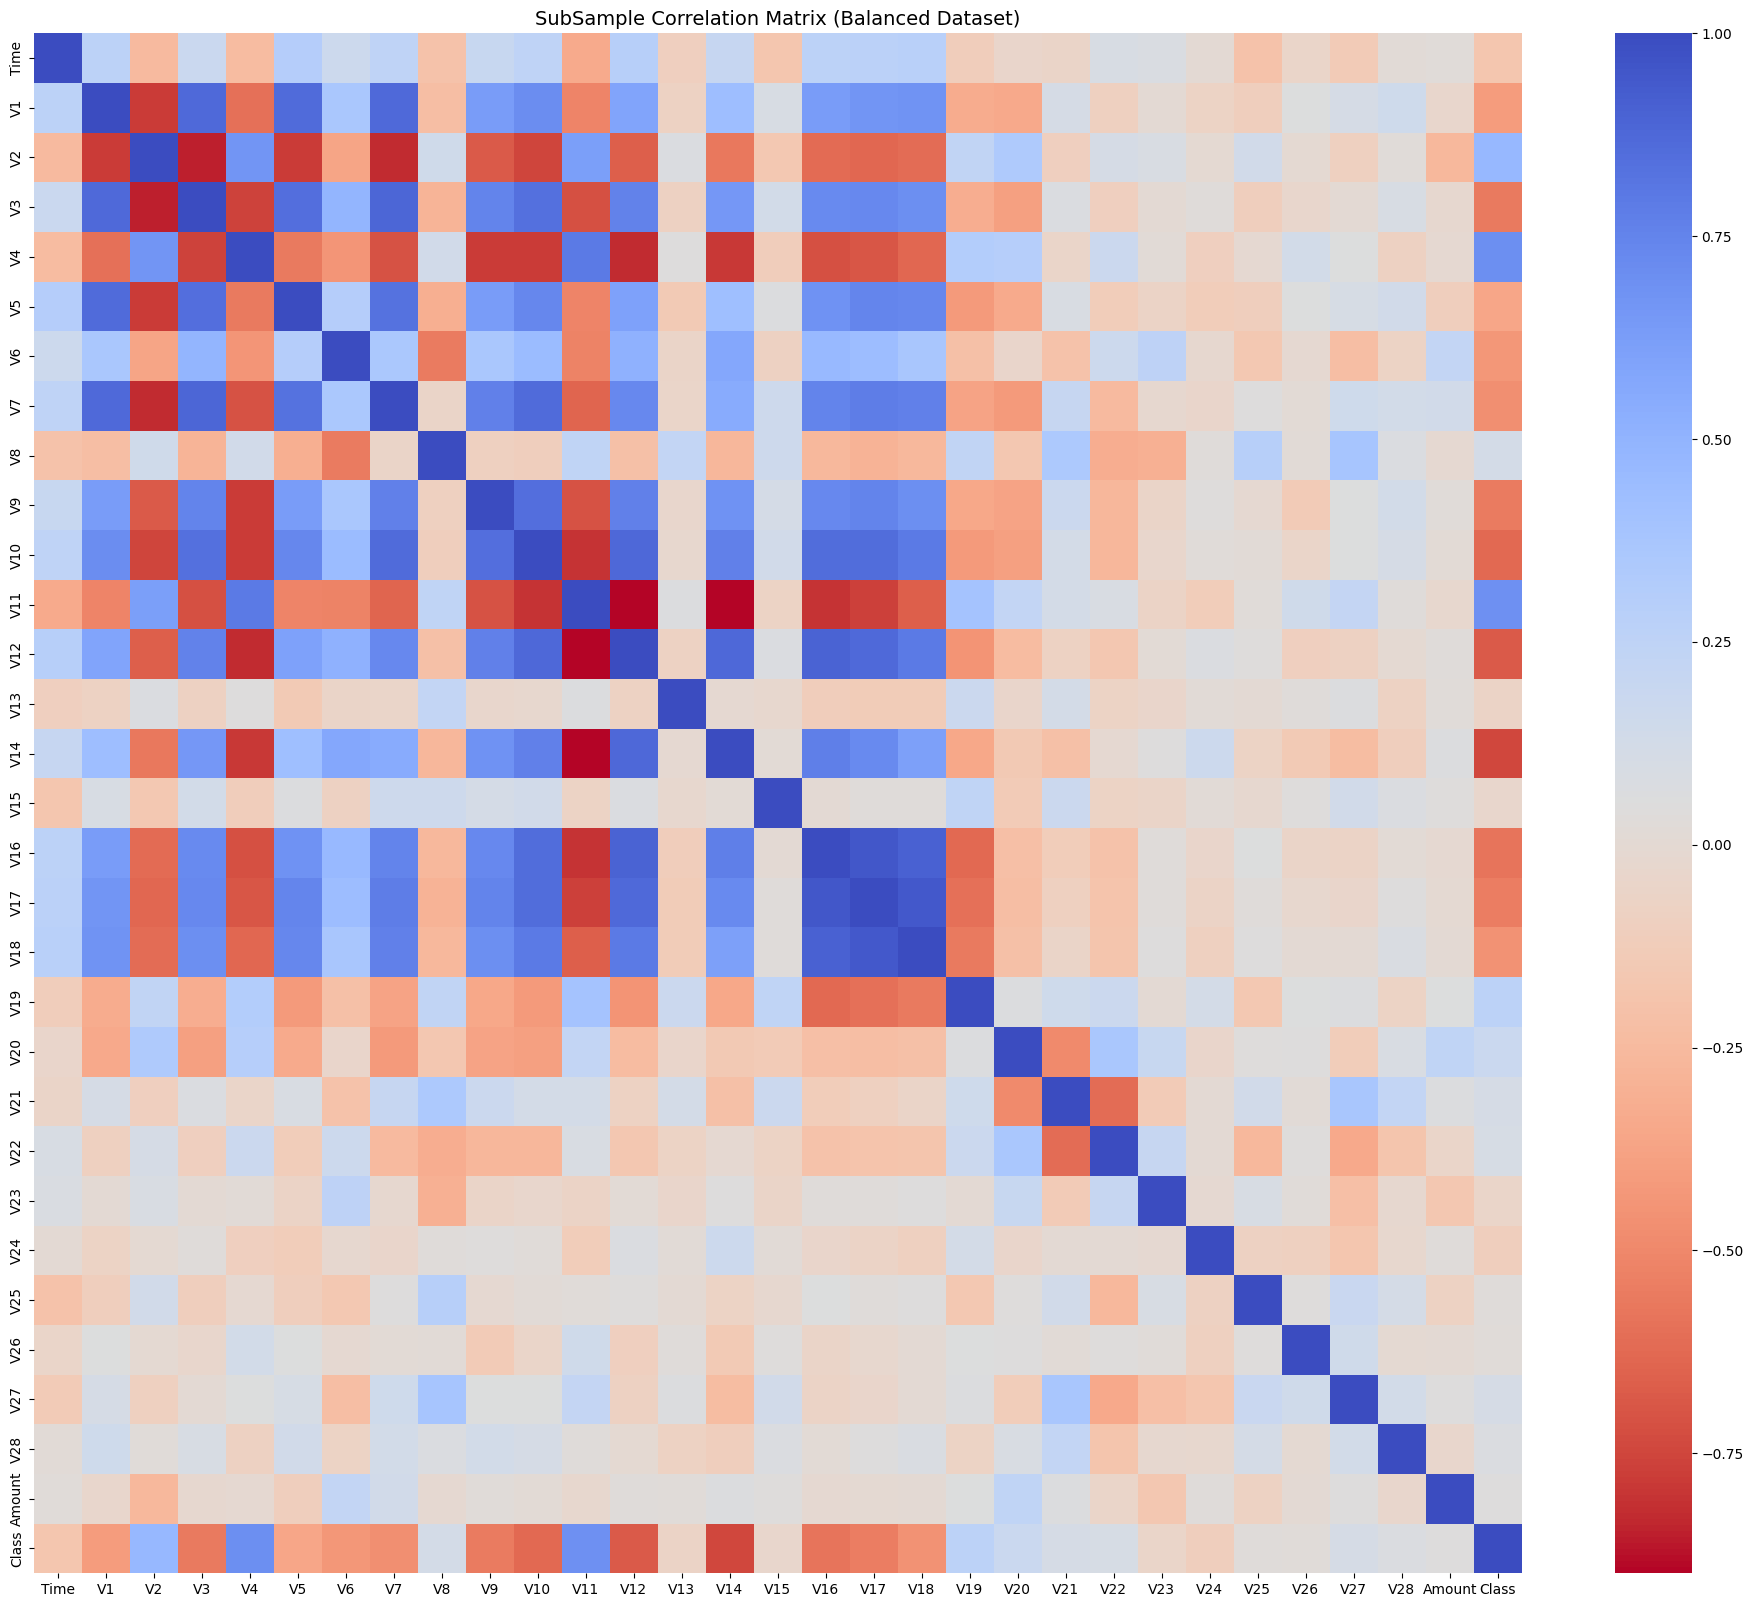

Key Negative Correlations (The lower the feature value, the more likely it is a fraud):
V14   -0.744855
V12   -0.678060
V10   -0.629054
V16   -0.584728
V3    -0.557682
Name: Class, dtype: float64

Key Positive Correlations (The higher the feature value, the more likely it is a fraud):
V4     0.696688
V11    0.689637
V2     0.473475
V19    0.262592
V20    0.183601
Name: Class, dtype: float64


In [6]:
# Random undersampling to create a balanced sub-sample for correlation
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0].sample(n=len(fraud_df), random_state=42)
normalized_df = pd.concat([fraud_df, non_fraud_df])
new_df = normalized_df.sample(frac=1, random_state=42) # Shuffle

# Heatmap
sub_sample_corr = new_df.corr()
plt.figure(figsize=(24, 20))
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('SubSample Correlation Matrix (Balanced Dataset)', fontsize=14)
plt.show()

print("Key Negative Correlations (The lower the feature value, the more likely it is a fraud):")
print(sub_sample_corr['Class'].sort_values()[:5])
print("\nKey Positive Correlations (The higher the feature value, the more likely it is a fraud):")
print(sub_sample_corr['Class'].sort_values(ascending=False)[1:6])

### 4. Outlier Analysis (Boxplots)

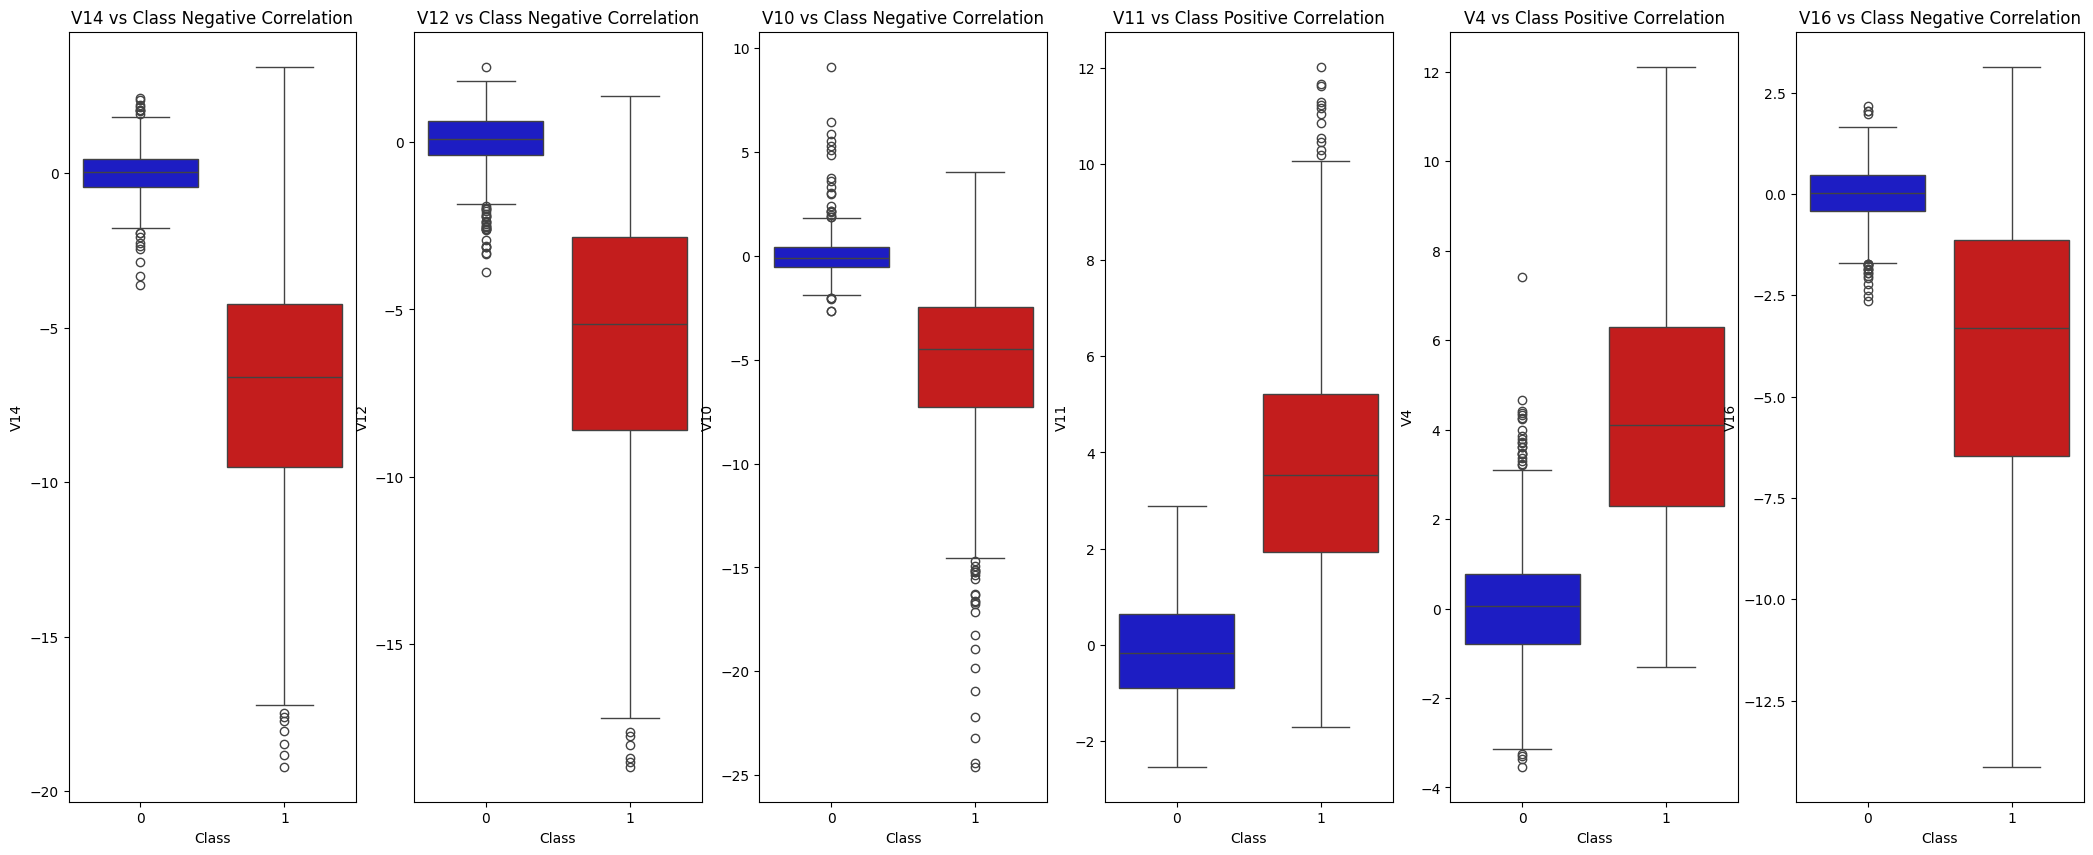

In [7]:
fig, axes = plt.subplots(ncols=6, figsize=(26, 10))
colors = ["#0101DF", "#DF0101"]

sns.boxplot(x="Class", y="V14", hue="Class", data=new_df, palette=colors, ax=axes[0], legend=False)
axes[0].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", hue="Class", data=new_df, palette=colors, ax=axes[1], legend=False)
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", hue="Class", data=new_df, palette=colors, ax=axes[2], legend=False)
axes[2].set_title('V10 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V11", hue="Class", data=new_df, palette=colors, ax=axes[3], legend=False)
axes[3].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", hue="Class", data=new_df, palette=colors, ax=axes[4], legend=False)
axes[4].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V16", hue="Class", data=new_df, palette=colors, ax=axes[5], legend=False)
axes[5].set_title('V16 vs Class Negative Correlation')

plt.show()

### 5. Statistical Testing (T-test/Mann-Whitney)

In [8]:
# T-Test Example on V14 between Class 0 and Class 1 in the subsample
v14_fraud = new_df['V14'].loc[new_df['Class'] == 1].values
v14_normal = new_df['V14'].loc[new_df['Class'] == 0].values

t_stat, p_val = stats.ttest_ind(v14_fraud, v14_normal)
print(f"T-test on V14 (Subsample): t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: The difference in V14 means between Fraud and Normal is statistically significant.")
else:
    print("Conclusion: The difference in V14 means is not statistically significant.")

T-test on V14 (Subsample): t-statistic = -34.2993, p-value = 4.5255e-168
Conclusion: The difference in V14 means between Fraud and Normal is statistically significant.


### 6. Data Cleaning, Scaling, and Pre-processing for Modeling

In [9]:
print("Applying RobustScaler to 'Amount' and 'Time'...")
rob_scaler = RobustScaler()

# We scale on the FULL dataset
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

# Insert scaled columns at the beginning
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)
print("Scaling complete. Re-ordered columns.")

Applying RobustScaler to 'Amount' and 'Time'...
Scaling complete. Re-ordered columns.


In [10]:
output_dir = '../data'

# S'assurer que le dossier existe (au cas où)
os.makedirs(output_dir, exist_ok=True)

# Définir le nom du nouveau fichier
output_file_path = os.path.join(output_dir, 'creditcard_scaled.csv')

# Exporter le dataframe complet (df) au format CSV
# index=False permet de ne pas sauvegarder la colonne des numéros de ligne (0, 1, 2...)
df.to_csv(output_file_path, index=False)

print(f"✅ Le dataset mis à l'échelle a été sauvegardé avec succès dans : {output_file_path}")


✅ Le dataset mis à l'échelle a été sauvegardé avec succès dans : ../data/creditcard_scaled.csv


In [11]:
print("\nPreparing for Modeling: Split Train/Test and apply SMOTE to Train only")
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data FIRST to avoid data leakage during SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Original X_train shape: {X_train.shape}, Original y_train shape: {y_train.shape}")

print("\nApplying SMOTE to X_train...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE applied. New X_train_sm shape: {X_train_sm.shape}, New y_train_sm shape: {y_train_sm.shape}")
print(f"Class distribution after SMOTE on training set:\n{y_train_sm.value_counts()}")

print("\nEDA and Feature Engineering pipeline complete. Data is ready for model training.")


Preparing for Modeling: Split Train/Test and apply SMOTE to Train only
Original X_train shape: (226980, 30), Original y_train shape: (226980,)

Applying SMOTE to X_train...


SMOTE applied. New X_train_sm shape: (453204, 30), New y_train_sm shape: (453204,)
Class distribution after SMOTE on training set:
Class
0    226602
1    226602
Name: count, dtype: int64

EDA and Feature Engineering pipeline complete. Data is ready for model training.


### 7. Algorithm Choice and Model Training
As stated in the architecture document (Step 3.3), we have labels for our transactions (Class 0 for normal, Class 1 for fraud). Therefore, we will use supervised learning algorithms.

We will train two models:
1. **Logistic Regression**: A simple and interpretable baseline model.
2. **Random Forest**: A powerful ensemble method that often performs well on tabular data.\n3. **XGBoost**: An advanced gradient boosting model known for high performance.

We will train these models on the SMOTE-augmented training set (`X_train_sm`, `y_train_sm`) and evaluate them on the original test set (`X_test`, `y_test`).

The most critical metric for fraud detection is **Recall** (Sensitivity), as we want to detect as many fraudulent transactions as possible, minimizing False Negatives. However, we also need to balance this with Precision to avoid too many False Positives.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
, XGBClassifier

'XGBClassifier'

#### Model 1: Logistic Regression

In [13]:
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sm, y_train_sm)

print("Evaluating Logistic Regression on Test Set...")
y_pred_log_reg = log_reg.predict(X_test)
y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log_reg):.4f}")

Training Logistic Regression...


Evaluating Logistic Regression on Test Set...

Confusion Matrix:
 [[55194  1457]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

ROC-AUC Score: 0.9601


#### Model 2: Random Forest

In [14]:
print("Training Random Forest (this might take a few minutes)...\n")
# We use n_jobs=-1 to use all CPU cores and speed up training
rf_clf = RandomForestClassifier(
    n_estimators=200,          # On double le nombre d'arbres (par défaut 100). Plus robuste, meilleure généralisation.
    max_depth=40,              # On limite la profondeur à 40 niveaux. Un arbre illimité risque d'apprendre le "bruit" par cœur.
    min_samples_split=35,      # Il faut au moins 10 transactions dans un nœud pour faire une division. Évite les règles trop spécifiques.
    min_samples_leaf=15,       # Chaque feuille finale (décision) doit contenir au moins 5 transactions. Rend les prédictions plus stables.
    bootstrap=True,            # Utilisation du bagging (tirer des sous-échantillons au hasard avec remplacement), garantit la diversité.
    random_state=42,           # Pour que les résultats soient reproductibles à chaque fois que tu relances la cellule.
    n_jobs=-1                  # Utilise tous les cœurs de ton processeur pour accélérer l'entraînement.
)
rf_clf.fit(X_train_sm, y_train_sm)

print("Evaluating Random Forest on Test Set...")
y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
, XGBClassifier

Training Random Forest (this might take a few minutes)...



Evaluating Random Forest on Test Set...



Confusion Matrix:
 [[56633    18]
 [   19    76]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.80      0.80        95

    accuracy                           1.00     56746
   macro avg       0.90      0.90      0.90     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC Score: 0.9797


'XGBClassifier'

### Conclusion
Based on the results, we can see how both models perform. Random Forest generally provides better Precision and overall ROC-AUC, but we must carefully check the Recall for Class 1 (Fraud) to decide which model to put into production e.g in the `model.py` and `train.py` scripts later.

### 8. Model Serialization (Step 3.5)
We have chosen the **Random Forest** model due to its high precision and robust performance. Now, we must save (serialize) this trained model and the `RobustScaler` so they can be used in production later in the inference API.

In [ ]:
import joblib

models_dir = '../app'
os.makedirs(models_dir, exist_ok=True)

# Save the trained Random Forest model
model_path = os.path.join(models_dir, 'random_forest_fraud_model.joblib')
joblib.dump(rf_clf, model_path)
print(f"✅ Model saved successfully at: {model_path}")

# Save the RobustScaler
# For the scaler, we need to ensure it was saved previously or we need to save the one we fit.
scaler_path = os.path.join(models_dir, 'robust_scaler.joblib')
joblib.dump(rob_scaler, scaler_path)
print(f"✅ Scaler saved successfully at: {scaler_path}")

✅ Model saved successfully at: ../app/random_forest_fraud_model.joblib
✅ Scaler saved successfully at: ../app/robust_scaler.joblib
